# BUSA8001 Programming Task 2  

**Assignment Points**: 100    
**Due Date**: Friday of Week 11 (18 October 2024) at 11:59pm   




---

## About This Assignment
Customer segmentation is the process of dividing customers into groups based on common characteristics so companies can market to each group effectively and appropriately. It can be employed by all types of business, regardless of size, industry and whether they sell online or in person. For example, a small business selling guitars might decide to promote lower-priced products to younger guitarists and higher-priced premium guitars to older musicians based on segment knowledge which tells them that younger musicians have less disposable income than their older counterparts.  

<hr style="width:35%;margin-left:0;"> 

## Task

You are employed by a large travel agency to perform customer segmentation analysis. You are provided with a dataset of 2,000 customers collected through their bookings and interactions with the agency. The dataset includes variables such as customer age, gender, annual income, etc.

Your task is to analyse the data in Python using relevant techniques covered in lectures and identify distinct customer segments within the dataset. You will then compile your results into tables and diagrams and writeup a report of up to **1,000 words** (excluding tables and figures). Ensure your report is informative, intuitive, and easily understandable for management, who may not have a technical background.

Your report should address the questions listed below under the following headings:

1. **Word count** (if missing -5 marks)
    - Include the word count of your report 
2. **Introduction** (10 marks)
    - Describe the problem, explain what you aim to achieve by solving it, outline the approach you will take to address it, and specify the data you will use
3. **Exploratory Data Analysis** (20 marks)
    - Perform basic exploratory data analysis, present and comment on key summary statistics, etc.
    - Provide charts (e.g. histograms, pie charts) where appropriate
4. **Customer Segmentation** (40 marks)
    - Standardise the two numeric variables using StandardScaler
    - Choose the optimal number of customer segments/clusters using the Elbow Method and three appropriately chosen Silhouette Plots
    - After identifying the optimal number of clusters, estimate the clusters using both the K-means++ and Agglomerative Clustering techniques. (Use all variables without applying any dimensionality reduction techniques)
    - Provide a separate table for each clustering technique that contains the cluster centers (for all variables), as well as the number of customers in each cluster
    - Interpret each of the identified clusters (for both clustering techniques) in terms of customer attributes, i.e. profile the clients in each cluster
        - E.g., Cluster 1 may be a cluster of young, single females employed as managers on high incomes and living in large cities
     - Compare the customer segments identified by the two techniques. Do any clusters overlap?
6. **Recommendations** (20 marks)
    - Suggest marketing strategies and techniques that could be used to target customer segements previously identified using the K-means++ method 
7. **Conclusion** (10 marks)
    - A summary of what you have done in the report 
    
---
---


## Assignment Submission   
You will need to submit two files:   

1. A PDF document containing your report for company management submission. Ensure it's comprehensive, including all relevant tables and graphs generated from the Jupyter notebook that you also submit. I suggest drafting the report in Word and then converting it to PDF for submission.
2. Your Jupyter Notebook containing the Python code used in your analysis. Ensure that your code is well-organized, easy to understand, and capable of generating all the outputs included in the report (will be used to verify your analysis presented in the submitted report).

## Marking Criteria

- To receive full marks your solutions must satisfy the following criteria:
    - Provide numerically correct answers;
    - Use Python methods and libraries covered in lectures;
    - Do not include irrelevant material in the report (that you do not discuss);
    - When including tables and charts label them properly;
    - Each included table and chart you include in the report needs to be discussed in text;
    - The report is to be read by marketing managers who may not have the expertise to understand technical terms; 
        - It should be written in clear and easy to understand sentences.
    - Report must contain the word count
    - See Marking Rubric file for details


# Name: Samrendra Narayan Singh

# Student ID: 47961171

In [1]:
#Importing required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm


C:\Users\hp\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
#Importing and reading required files

df = pd.read_csv("D:\MQU\Session 2, 2024\Applied Predictive Analytics\BUSA8001_Assignment2\data\data.csv")

In [5]:
#Finding dimensions of the data 

df.shape

(2000, 7)

# df has 2000 rows and 7 columns 

In [6]:
#Summary statistics

df.describe()

,Gender,Marital Status,Age,Education,Income,Occupation,Settlement Size
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.60450,0.500500,40.823500,1.456500,137516.196500,0.612500,0.834000
std,0.48908,0.500125,9.455848,0.783846,46184.296588,0.674219,0.967942
min,0.00000,0.000000,20.000000,0.000000,35832.000000,0.000000,0.000000
25%,0.00000,0.000000,33.000000,1.000000,101262.750000,0.000000,0.000000
50%,1.00000,1.000000,40.000000,1.000000,133004.000000,1.000000,0.000000
75%,1.00000,1.000000,48.000000,2.000000,171232.500000,1.000000,2.000000
max,1.00000,1.000000,76.000000,3.000000,309364.000000,2.000000,2.000000


In [7]:
#Finding the number of null/ missing values

df.isna().sum()

Gender             0
Marital Status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement Size    0
dtype: int64

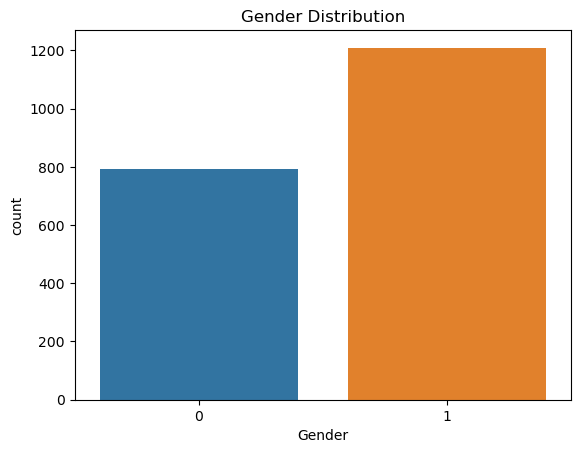

In [11]:
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

C:\Users\hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


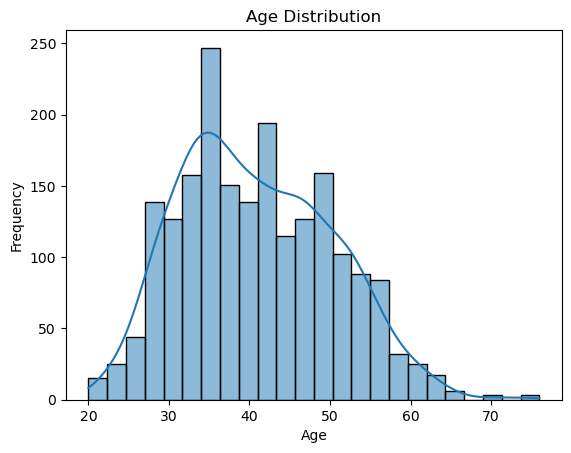

In [15]:
# Histograms for numeric variables
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [57]:
#Encoding Categorical variables

df_encode = pd.get_dummies(df, columns=['Gender'], drop_first=True)

In [17]:
#Creating list of numerical features and standardising them

scaler = StandardScaler()
Num_Features = ['Income', 'Age']
df[Num_Features] = scaler.fit_transform(df[Num_Features])



In [18]:
#One hot encoding categorical features
Categorical = ['Gender', 'Marital Status', 'Education', 'Settlement Size', 'Occupation']
df_encode = pd.get_dummies(df, columns=Categorical)

In [19]:
#Creating the feature matrix for clustering
x = df_encode.values

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable 

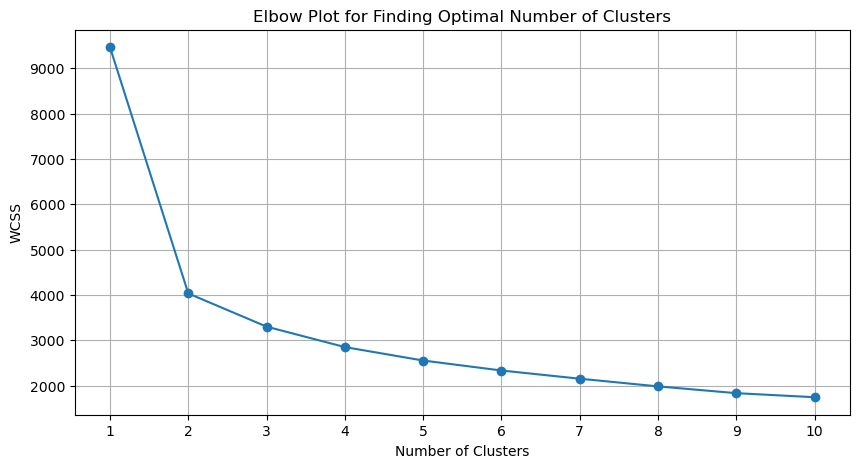

In [20]:
#Finding Within Cluster Sum of Squares

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Plot for Finding Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


silhouette_avg: 0.51


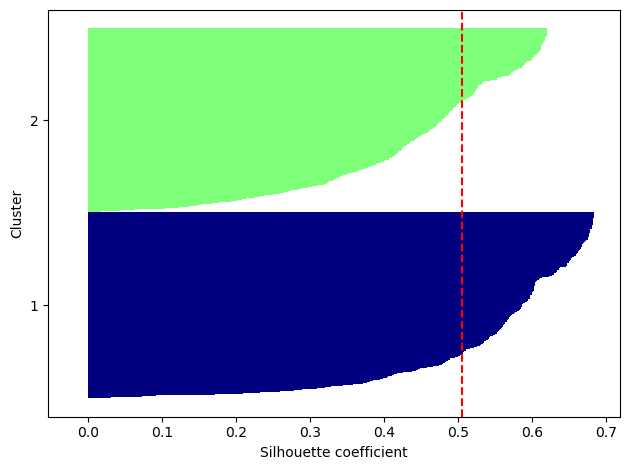

In [22]:
#Plot all silhouette coefficients for each example (from smallest to largest) grouped by clusters  
#Compute and plot the average silhouette coefficient across all observations  
      
KM = KMeans(n_clusters=2,  
            init='k-means++', 
            n_init=10, 
            max_iter=300,
            tol=1e-04,
            random_state=0)

y_KM = KM.fit_predict(x)
# print(y_km)

cluster_labels = np.unique(y_KM)
# print(cluster_labels)

n_clusters = cluster_labels.shape[0]

silhouette_vals = silhouette_samples(x, y_KM, metric='euclidean')
# print('silhouette_vals\n', silhouette_vals)

## ------- plotting silhouette values -------

y_ax_lower, y_ax_upper = 0, 0
yticks = []

for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_KM == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0, edgecolor='none', color=color)
    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)
    
    
silhouette_avg = np.mean(silhouette_vals)
print(f'silhouette_avg: {silhouette_avg:.2f}')

plt.axvline(silhouette_avg, color="red", linestyle="--") # plot vertical average line

plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')

plt.tight_layout()
#plt.savefig('images/11_04.png', dpi=300)
plt.show()

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


silhouette_avg: 0.39


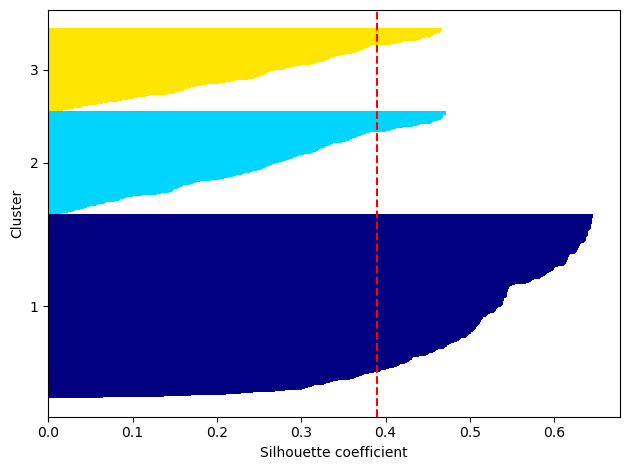

In [66]:
KM = KMeans(n_clusters=3,  
            init='k-means++', 
            n_init=10, 
            max_iter=300,
            tol=1e-04,
            random_state=0)

y_KM = KM.fit_predict(x)
# print(y_km)

cluster_labels = np.unique(y_KM)
# print(cluster_labels)

n_clusters = cluster_labels.shape[0]

silhouette_vals = silhouette_samples(x, y_KM, metric='euclidean')
# print('silhouette_vals\n', silhouette_vals)

## ------- plotting silhouette values -------

y_ax_lower, y_ax_upper = 0, 0
yticks = []

for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_KM == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0, edgecolor='none', color=color)
    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)
    
    
silhouette_avg = np.mean(silhouette_vals)
print(f'silhouette_avg: {silhouette_avg:.2f}')

plt.axvline(silhouette_avg, color="red", linestyle="--") # plot vertical average line

plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')

plt.tight_layout()
#plt.savefig('images/11_04.png', dpi=300)
plt.show()

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


silhouette_avg: 0.31


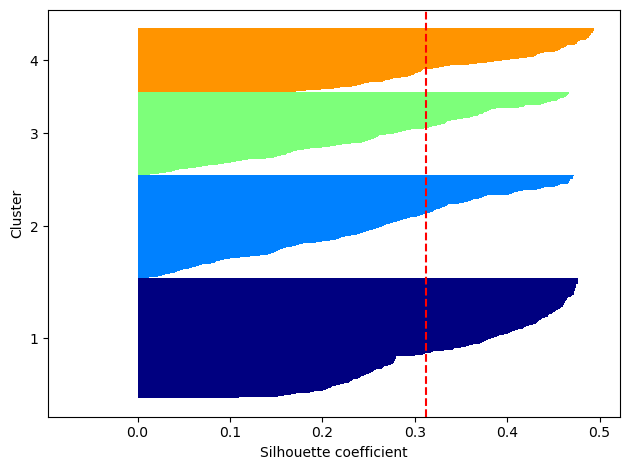

In [23]:
KM = KMeans(n_clusters=4,  
            init='k-means++', 
            n_init=10, 
            max_iter=300,
            tol=1e-04,
            random_state=0)

y_KM = KM.fit_predict(x)
# print(y_km)

cluster_labels = np.unique(y_KM)
# print(cluster_labels)

n_clusters = cluster_labels.shape[0]

silhouette_vals = silhouette_samples(x, y_KM, metric='euclidean')
# print('silhouette_vals\n', silhouette_vals)

## ------- plotting silhouette values -------

y_ax_lower, y_ax_upper = 0, 0
yticks = []

for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_KM == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0, edgecolor='none', color=color)
    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)
    
    
silhouette_avg = np.mean(silhouette_vals)
print(f'silhouette_avg: {silhouette_avg:.2f}')

plt.axvline(silhouette_avg, color="red", linestyle="--") # plot vertical average line

plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')

plt.tight_layout()
#plt.savefig('images/11_04.png', dpi=300)
plt.show()

# The average silhouette coefficient  for two clusters (0.51) is highest among number of clusters ( two, three and four). Hence the optimum number of clusters is two. 

In [24]:
AGLC = AgglomerativeClustering(n_clusters=3, 
                             metric='euclidean', 
                             linkage='complete')
labels = AGLC.fit_predict(x)
print('Cluster labels: %s' % labels)

Cluster labels: [0 0 0 ... 0 0 0]


In [25]:
# Implementing clustering algorithms
# K-means++
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
kmeans.fit(df_encode)
df_encode['KMeans_Cluster'] = kmeans.labels_

# Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=2)
agg_clusters = agg_clustering.fit_predict(df_encode)
df_encode['Agg_Cluster'] = agg_clusters

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


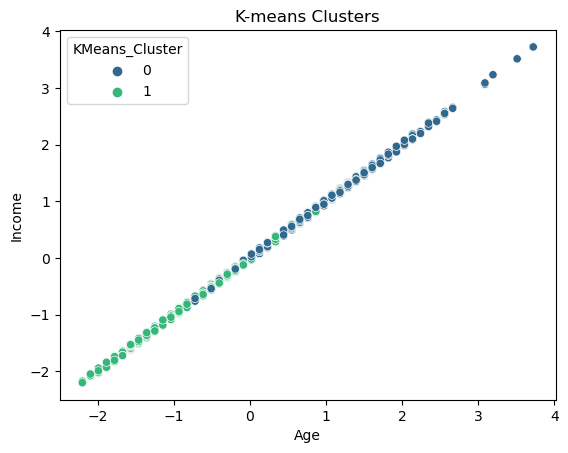

In [26]:
#Visualizing clusters
sns.scatterplot(x='Age', y='Income', hue='KMeans_Cluster', data=df_encode, palette='viridis')
plt.title('K-means Clusters')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

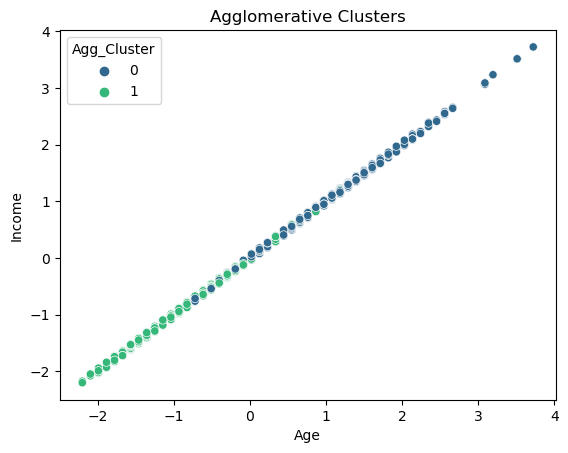

In [27]:
sns.scatterplot(x='Age', y='Income', hue='Agg_Cluster', data=df_encode, palette='viridis')
plt.title('Agglomerative Clusters')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [28]:
# Interpreting clusters
cluster_summary = df_encode.groupby('KMeans_Cluster').mean()
print(cluster_summary)

                     Age    Income  Gender_0  Gender_1  Marital Status_0  \
KMeans_Cluster                                                             
0               0.753173  0.753792  0.139980  0.860020          0.004028   
1              -0.742702 -0.743312  0.647468  0.352532          0.988083   

                Marital Status_1  Education_0  Education_1  Education_2  \
KMeans_Cluster                                                            
0                       0.995972     0.001007     0.070493     0.756294   
1                       0.011917     0.189672     0.801390     0.005958   

                Education_3  Settlement Size_0  Settlement Size_1  \
KMeans_Cluster                                                      
0                  0.172205           0.194361           0.004028   
1                  0.002979           0.930487           0.067527   

                Settlement Size_2  Occupation_0  Occupation_1  Occupation_2  \
KMeans_Cluster                        